# Airbnb Listing Segmentation

Follows **`docs/cluster_analysis_method.md`** phase-by-phase.

**Dataset:** `Data/processed/listings_all_cities.parquet` — 42 823 listings, Madrid / Barcelona / Málaga  
**Goal:** Cluster listings on *attributes only* so the resulting segments can be used as a grouping variable in the downstream price and occupancy prediction models.

| Excluded from ALL clustering features | Reason |
|---|---|
| `price`, `price_cat` | target |
| `estimated_occupancy_l365d`, `estimated_revenue_l365d` | targets / leakage |
| `number_of_reviews*`, `reviews_per_month`, `availability_*` | near-direct occupancy leakage |
| `days_since_*`, `review_span_years` | review-activity proxies (flag for occupancy model too) |

In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
DATA_PATH    = "../Data/processed/listings_all_cities.parquet"

# ── columns to keep in df but NEVER feed to K-Means ─────────────────────────
TARGETS = ['price', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'price_cat']

OCCUPANCY_LEAKAGE = [
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'number_of_reviews_ly', 'reviews_per_month',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'availability_eoy',
]

REVIEW_ACTIVITY = ['days_since_first_review', 'days_since_last_review', 'review_span_years']

print('Setup complete — RANDOM_STATE =', RANDOM_STATE)

Setup complete — RANDOM_STATE = 42


## Phase 1 — Data Audit

In [62]:
df_raw = pd.read_parquet(DATA_PATH)
df     = df_raw.copy()

print(f"Shape: {df.shape}")
print(f"\nCity counts:\n{df['city'].value_counts()}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")
df.describe().round(2)

Shape: (42823, 90)

City counts:
city
Madrid       18862
Barcelona    15199
Málaga        8762
Name: count, dtype: int64

Dtypes:
int64             34
float64           25
object            18
datetime64[ns]     5
bool               4
category           2
category           1
category           1
Name: count, dtype: int64


,id,scrape_id,last_scraped,host_id,host_since,host_response_rate,host_acceptance_rate,latitude,longitude,accommodates,...,has_crib,has_lock_on_bedroom_door,has_hot_water,has_patio_or_balcony,has_private_entrance,has_hangers,has_hair_dryer,has_dishes_and_silverware,has_room_darkening_shades,bundle_1
count,4.282300e+04,4.282300e+04,42823,4.282300e+04,42727,42823.00,42823.00,42823.00,42823.00,42823.00,...,42823.00,42823.00,42823.0,42823.00,42823.00,42823.00,42823.00,42823.00,42823.00,42823.00
mean,7.533742e+17,2.025092e+13,2025-09-17 18:39:56.413142272,2.558896e+08,2018-09-09 07:08:43.650150912,0.87,0.83,40.01,-1.76,3.53,...,0.19,0.13,0.8,0.15,0.16,0.72,0.76,0.74,0.40,0.17
min,1.867400e+04,2.025091e+13,2025-09-14 00:00:00,1.070400e+04,2009-03-19 00:00:00,0.00,0.00,36.65,-4.58,1.00,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.437262e+07,2.025091e+13,2025-09-14 00:00:00,3.536358e+07,2015-06-13 00:00:00,0.91,0.84,40.40,-3.71,2.00,...,0.00,0.00,1.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00
50%,9.194596e+17,2.025091e+13,2025-09-15 00:00:00,2.146843e+08,2018-09-10 00:00:00,1.00,0.99,40.43,-3.70,3.00,...,0.00,0.00,1.0,0.00,0.00,1.00,1.00,1.00,0.00,0.00
75%,1.258643e+18,2.025091e+13,2025-09-15 00:00:00,4.500060e+08,2022-03-14 00:00:00,1.00,1.00,41.38,2.16,4.00,...,0.00,0.00,1.0,0.00,0.00,1.00,1.00,1.00,1.00,0.00
max,1.520070e+18,2.025093e+13,2025-09-30 00:00:00,7.202991e+08,2025-09-22 00:00:00,1.00,1.00,41.46,2.22,16.00,...,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00
std,5.687788e+17,6.405494e+06,NaN,2.236215e+08,NaN,0.29,0.30,1.72,2.93,2.10,...,0.39,0.34,0.4,0.36,0.37,0.45,0.43,0.44,0.49,0.38


In [63]:
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print("Columns with missing values (% of rows):")
print(null_pct.round(1).to_string())

Columns with missing values (% of rows):
neighbourhood_group_cleansed    20.5
review_scores_cleanliness       17.3
review_scores_checkin           17.3
review_scores_accuracy          17.3
days_since_first_review         17.3
review_scores_communication     17.3
days_since_last_review          17.3
review_scores_value             17.3
review_scores_location          17.3
review_span_years               17.3
review_scores_rating            17.3
description                      3.0
host_name                        0.2
host_tenure_years                0.2
host_verifications               0.2
host_since                       0.2
maximum_maximum_nights           0.0
minimum_maximum_nights           0.0
maximum_minimum_nights           0.0
minimum_minimum_nights           0.0


## Phase 2 — Cleaning & Impossible-Value Removal

Drop only physically impossible / data-entry-error records (not statistical outliers — that is Phase 4).

| Column | Threshold | Rationale |
|---|---|---|
| `minimum_nights` | > 365 | Airbnb hard cap is 1 year; tail shows 865, 600, 500 |
| `beds` | > 100 | beds = 127 is impossible; IQR handles the 24–30 range |
| `bathrooms_number` | > 15 | 19-bathroom entry is implausible |

In [64]:
for col in ['beds', 'minimum_nights', 'bathrooms_number']:
    print(f"{col} (top 10):", df[col].sort_values(ascending=False).head(10).tolist())

beds (top 10): [127, 30, 30, 30, 30, 27, 26, 25, 25, 24]
minimum_nights (top 10): [865, 600, 600, 600, 600, 500, 500, 400, 366, 365]
bathrooms_number (top 10): [19.0, 16.0, 15.0, 10.0, 10.0, 9.5, 9.0, 9.0, 8.5, 8.5]


In [65]:
n_before = len(df)
df = df[df['minimum_nights']    <= 365].copy()
df = df[df['beds']              <= 100].copy()
df = df[df['bathrooms_number']  <= 15 ].copy()
n_after = len(df)

print(f"Dropped: {n_before - n_after:,} rows ({(n_before - n_after) / n_before * 100:.2f}%)")
print(f"Remaining: {n_after:,} rows")

Dropped: 12 rows (0.03%)
Remaining: 42,811 rows


## Phase 3 — Distribution Checks & Transforms

Auto-classify columns into binary / continuous / categorical, then plot histograms for the continuous clustering candidates and confirm log transforms reduce right skew.

In [66]:
# Columns excluded from auto-classification (will be engineered, are IDs/text, or are leakage)
DROP_IDS      = ['id','scrape_id','host_id','host_name','name','description',
                 'neighborhood_overview','picture_url','host_about','host_verifications',
                 'license','source','amenities','bathrooms_description','host_location',
                 'latitude','longitude']
DROP_DATES    = ['host_since','last_scraped','calendar_last_scraped','first_review','last_review']
DROP_REDUNDANT = [
    'property_type',           # 71 levels → use property_type_std (6)
    'neighbourhood_cleansed',  # 210+ levels; only used for Málaga is_central flag
    'neighbourhood_group_cleansed',  # only used for Madrid/Barcelona is_central flag
    'host_response_rate', 'host_acceptance_rate',  # captured by *_cat
    'maximum_nights',
    'minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'review_scores_accuracy','review_scores_cleanliness','review_scores_checkin',
    'review_scores_communication','review_scores_location','review_scores_value',
]
WILL_ENGINEER = [
    'room_type','property_type_std','city',
    'host_response_time','host_response_rate_cat','host_acceptance_rate_cat',
]

EXCLUDE_FROM_CLASSIFY = set(
    DROP_IDS + DROP_DATES + DROP_REDUNDANT + WILL_ENGINEER
    + TARGETS + OCCUPANCY_LEAKAGE + REVIEW_ACTIVITY
)

binary_cols, continuous_cols, categorical_cols = [], [], []
for col in df.columns:
    if col in EXCLUDE_FROM_CLASSIFY:
        continue
    s = df[col].dropna()
    if (df[col].dtype == bool or
        (pd.api.types.is_numeric_dtype(df[col]) and
         s.nunique() == 2 and
         set(s.unique()).issubset({0, 1, True, False}))):
        binary_cols.append(col)
    elif pd.api.types.is_numeric_dtype(df[col]):
        continuous_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Binary ({len(binary_cols)}):",     binary_cols)
print(f"\nContinuous ({len(continuous_cols)}):", continuous_cols)
print(f"\nCategorical ({len(categorical_cols)}):", categorical_cols)

Binary (14): ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable', 'has_crib', 'has_lock_on_bedroom_door', 'has_hot_water', 'has_patio_or_balcony', 'has_private_entrance', 'has_hangers', 'has_hair_dryer', 'has_dishes_and_silverware', 'has_room_darkening_shades', 'bundle_1']

Continuous (10): ['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'review_scores_rating', 'calculated_host_listings_count', 'bathrooms_number', 'host_tenure_years', 'description_length', 'amenity_count']

Categorical (0): []


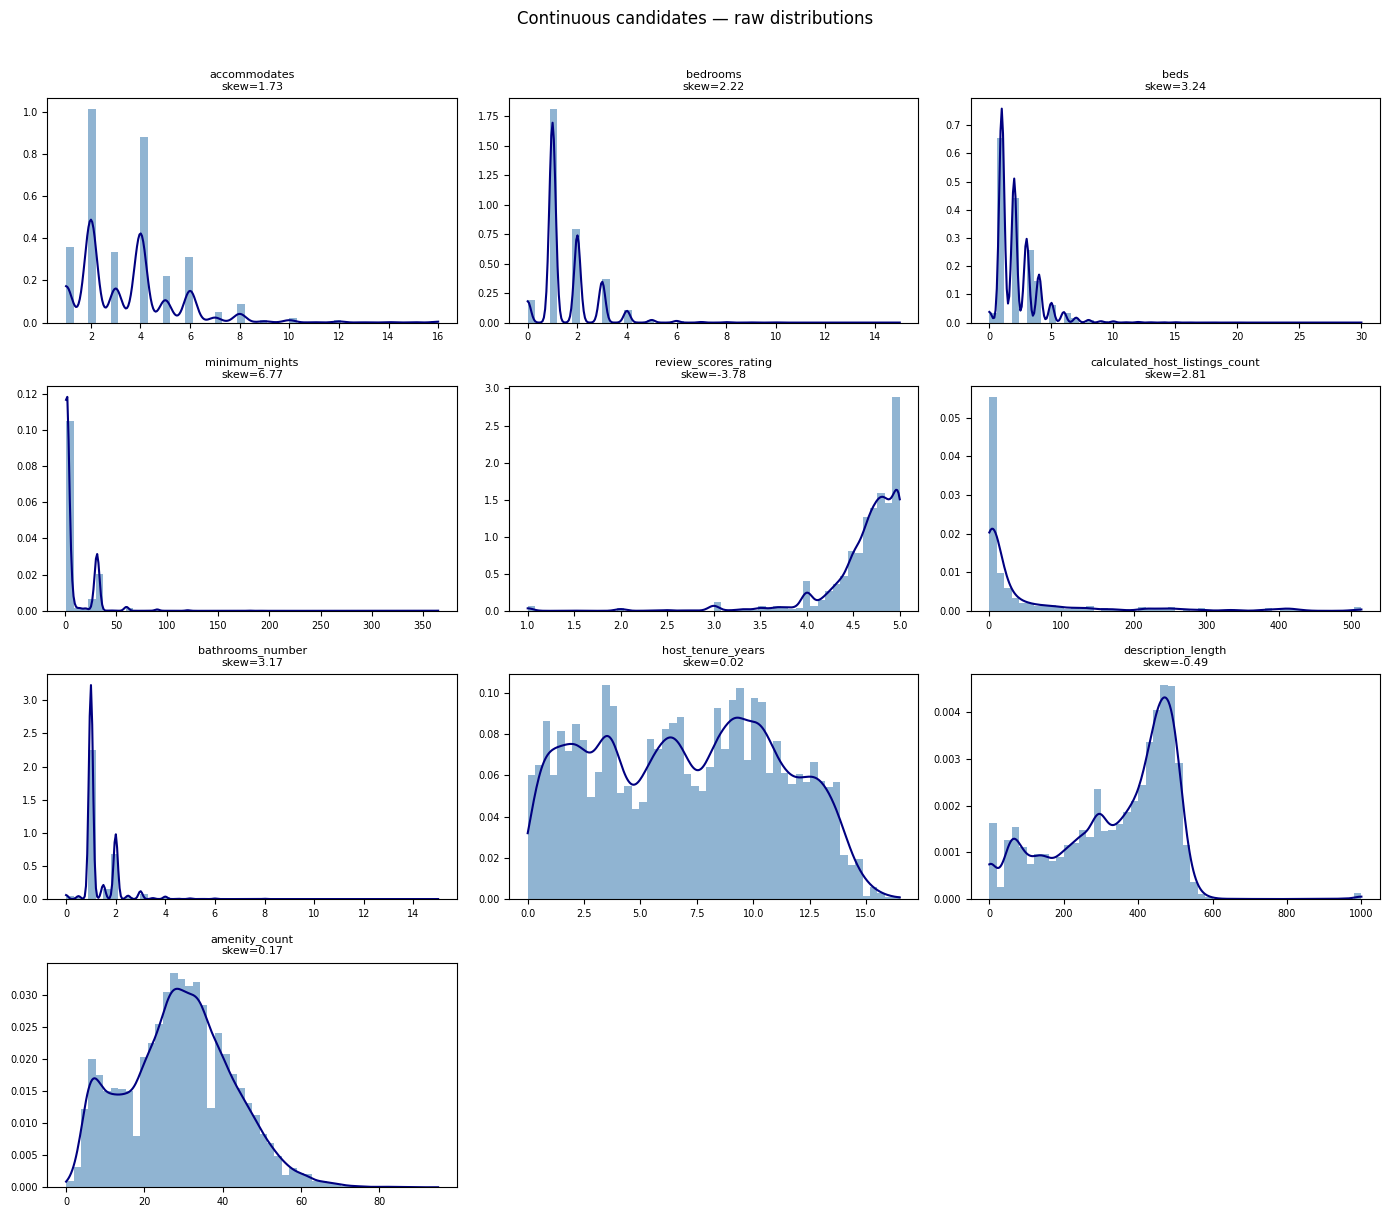

In [67]:
# Histogram + KDE grid for continuous clustering candidates
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='none')
    try:
        kde_x = np.linspace(data.min(), data.max(), 300)
        kde   = stats.gaussian_kde(data)
        axes[i].plot(kde_x, kde(kde_x), color='navy', lw=1.5)
    except Exception:
        pass
    axes[i].set_title(f"{col}\nskew={data.skew():.2f}", fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous candidates — raw distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

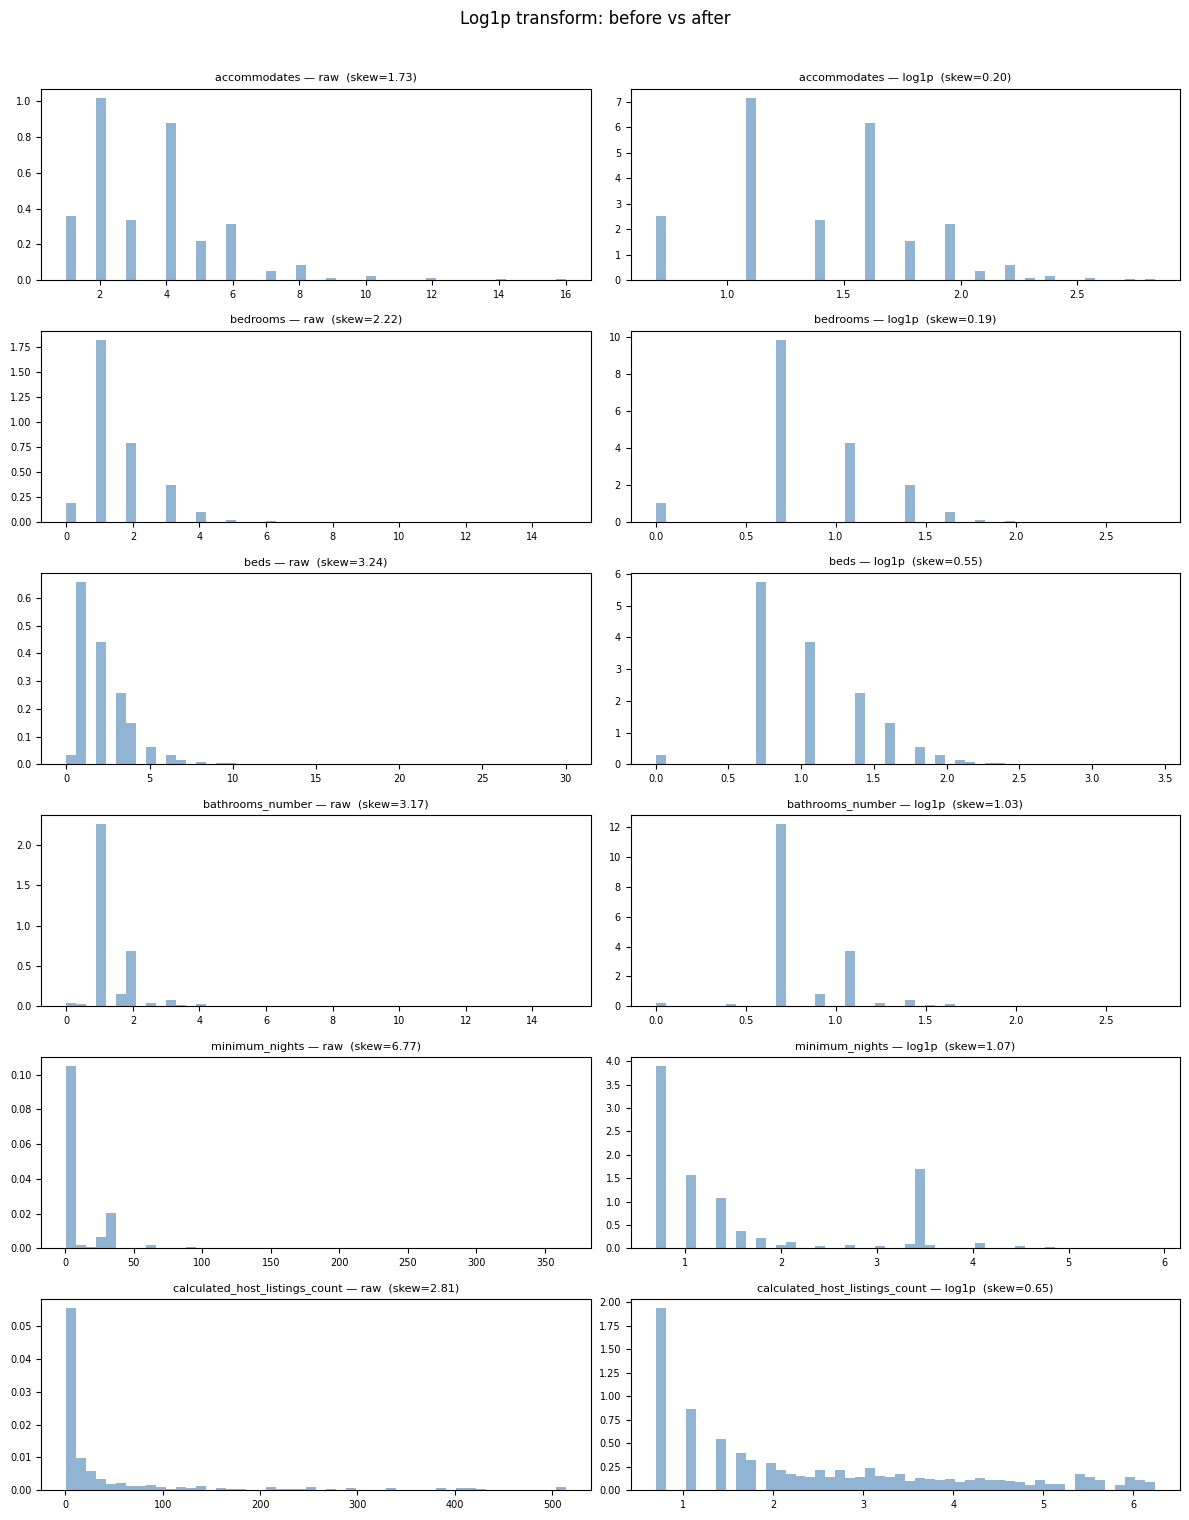

In [68]:
# Confirm log1p reduces right skew for the six flagged variables
LOG1P_COLS = ['accommodates','bedrooms','beds','bathrooms_number',
              'minimum_nights','calculated_host_listings_count']

fig, axes = plt.subplots(len(LOG1P_COLS), 2, figsize=(12, len(LOG1P_COLS) * 2.5))

for i, col in enumerate(LOG1P_COLS):
    raw  = df[col].dropna()
    logv = np.log1p(raw)
    for ax, data, label in zip(axes[i], [raw, logv], ['raw', 'log1p']):
        ax.hist(data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='none')
        ax.set_title(f"{col} — {label}  (skew={data.skew():.2f})", fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Log1p transform: before vs after', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Phase 4 — IQR Outlier Split (within city)

IQR bounds are computed **per city** to avoid Madrid's higher price range biasing the thresholds for Málaga.

- `df_clean` = rows where ≤ 1 continuous column is outside its city-specific IQR → fed to K-Means  
- `df_multi_outliers` = rows where > 1 column is out-of-bounds → manually-labelled **"Ultra / Extreme"** segment

In [69]:
# Continuous columns used for IQR flag counting (raw, before log transforms)
# description_length is excluded — a very long description is not a physically
# impossible value and should not route listings to the extreme-outlier bucket
CONTINUOUS_RAW = ['accommodates','bedrooms','beds','bathrooms_number',
                  'minimum_nights','host_tenure_years','review_scores_rating',
                  'calculated_host_listings_count']

def compute_iqr_flags(df_in, cols):
    """Return int flag matrix (1 = outside city-specific IQR)."""
    flag_df = pd.DataFrame(0, index=df_in.index, columns=cols)
    for city in df_in['city'].unique():
        mask      = df_in['city'] == city
        city_data = df_in.loc[mask, cols]
        Q1  = city_data.quantile(0.25)
        Q3  = city_data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        for col in cols:
            flag_df.loc[mask, col] = (
                (city_data[col] < lower[col]) | (city_data[col] > upper[col])
            ).astype(int)
    return flag_df

flag_matrix        = compute_iqr_flags(df, CONTINUOUS_RAW)
df['n_outlier_cols'] = flag_matrix.sum(axis=1)

df_clean         = df[df['n_outlier_cols'] <= 1].copy()
df_multi_outliers = df[df['n_outlier_cols'] >  1].copy()

print(f"df_clean:          {len(df_clean):>6,}  ({len(df_clean)/len(df)*100:.1f}%)")
print(f"df_multi_outliers: {len(df_multi_outliers):>6,}  ({len(df_multi_outliers)/len(df)*100:.1f}%)")
print(f"\nMulti-outlier breakdown by city:")
print(df_multi_outliers['city'].value_counts())
print(f"\nOutlier column distribution:")
print(df['n_outlier_cols'].value_counts().sort_index())

df_clean:          38,577  (90.1%)
df_multi_outliers:  4,234  (9.9%)

Multi-outlier breakdown by city:
city
Madrid       2826
Barcelona     884
Málaga        524
Name: count, dtype: int64

Outlier column distribution:
n_outlier_cols
0    28469
1    10108
2     2645
3      997
4      434
5      144
6       14
Name: count, dtype: int64


## Phase 5 — Missing-Value Imputation

Applied **separately** to `df_clean` and `df_multi_outliers` (stats computed independently — no leakage between subsets).

| Column | Missing | Strategy |
|---|---|---|
| `review_scores_rating` | 17.3% (zero-review listings) | Group mean within `city × room_type` among reviewed listings; city-level fallback |
| `host_tenure_years` | 0.2% | Group mean within `city`; global fallback |

In [70]:
def impute_subset(df_sub):
    df_sub = df_sub.copy()

    has_rev = df_sub['number_of_reviews'] > 0

    # review_scores_rating: compute fill values from reviewed listings only so
    # zero-review listings don't pollute group means.
    reviewed = df_sub[has_rev]
    city_room_means = (
        reviewed.groupby(['city', 'room_type'], observed=True)['review_scores_rating'].mean()
    )
    city_means  = reviewed.groupby('city', observed=True)['review_scores_rating'].mean()
    global_mean = float(reviewed['review_scores_rating'].mean())

    # Map fine-grained fill onto every row (NaN where group absent).
    # Cast to float — city/room_type can be Categorical, and .map() on a
    # Categorical returns a Categorical that rejects float fillna values.
    fine_fill = pd.Series(
        [city_room_means.get((c, r), np.nan)
         for c, r in zip(df_sub['city'], df_sub['room_type'])],
        index=df_sub.index, dtype=float,
    )
    city_fill = df_sub['city'].map(city_means).astype(float)

    # For reviewed listings: original → fine group mean → city mean → global
    filled_reviewed = (
        df_sub['review_scores_rating'].fillna(fine_fill).fillna(city_fill).fillna(global_mean)
    )
    # For zero-review listings: city mean of reviewed peers as a neutral prior.
    # has_reviews=0 (Phase 6) already flags these as unestablished in clustering.
    fill_zero_rev = city_fill.fillna(global_mean)

    # Use .values to avoid pandas block-level dtype coercion issues on older versions
    df_sub['review_scores_rating'] = np.where(
        has_rev.values, filled_reviewed.values, fill_zero_rev.values
    )

    # host_tenure_years: city-level mean, then global
    df_sub['host_tenure_years'] = (
        df_sub.groupby('city', observed=True)['host_tenure_years']
        .transform(lambda x: x.fillna(x.mean()))
    )
    df_sub['host_tenure_years'].fillna(df_sub['host_tenure_years'].mean(), inplace=True)

    return df_sub

df_clean          = impute_subset(df_clean)
df_multi_outliers = impute_subset(df_multi_outliers)

print("Remaining nulls in clustering cols after imputation:")
check_cols = ['review_scores_rating', 'host_tenure_years']
for col in check_cols:
    print(f"  df_clean[{col}]:          {df_clean[col].isna().sum()}")
    print(f"  df_multi_outliers[{col}]: {df_multi_outliers[col].isna().sum()}")

Remaining nulls in clustering cols after imputation:
  df_clean[review_scores_rating]:          0
  df_multi_outliers[review_scores_rating]: 0
  df_clean[host_tenure_years]:          0
  df_multi_outliers[host_tenure_years]: 0


## Phase 6 — Domain Feature Engineering

All flags are binary 0/1 and derived from listing **attributes only** (no target columns).

| Flag | Source | Logic |
|---|---|---|
| `has_reviews` | `number_of_reviews` | > 0 |
| `is_entire_place/private_room/hotel_hostel/shared_room` | `property_type_std` | equality |
| `is_madrid`, `is_barcelona` | `city` | equality; Málaga = reference (both = 0) |
| `is_central` | city-specific | Madrid: `neighbourhood_group_cleansed == 'Centro'`; Barcelona: `== 'Ciutat Vella'`; Málaga: `neighbourhood_cleansed == 'Centro'` |
| `is_fast_responder` | `host_response_time` | within an hour or within a few hours |
| `host_acceptance_rate_ord`, `host_response_rate_ord` | `*_cat` | ordinal: unknown=0, low=1, medium=2, high=3 |

In [71]:
def engineer_features(df_sub):
    df_sub = df_sub.copy()

    df_sub['has_reviews']    = (df_sub['number_of_reviews'] > 0).astype(int)

    df_sub['is_entire_place'] = (df_sub['property_type_std'] == 'Entire place').astype(int)
    df_sub['is_private_room'] = (df_sub['property_type_std'] == 'Private room').astype(int)
    df_sub['is_hotel_hostel'] = (df_sub['property_type_std'] == 'Hotel / Hostel').astype(int)
    df_sub['is_shared_room']  = (df_sub['property_type_std'] == 'Shared room').astype(int)

    df_sub['is_madrid']    = (df_sub['city'] == 'Madrid').astype(int)
    df_sub['is_barcelona'] = (df_sub['city'] == 'Barcelona').astype(int)

    # is_central: each city uses a different source column
    is_central = pd.Series(0, index=df_sub.index)
    is_central.loc[(df_sub['city'] == 'Madrid')    & (df_sub['neighbourhood_group_cleansed'] == 'Centro')]      = 1
    is_central.loc[(df_sub['city'] == 'Barcelona') & (df_sub['neighbourhood_group_cleansed'] == 'Ciutat Vella')] = 1
    is_central.loc[(df_sub['city'] == 'Málaga')    & (df_sub['neighbourhood_cleansed'] == 'Centro')]            = 1
    df_sub['is_central'] = is_central.values

    fast = {'within an hour', 'within a few hours'}
    df_sub['is_fast_responder'] = df_sub['host_response_time'].isin(fast).astype(int)

    rate_map = {'unknown': 0, 'low': 1, 'medium': 2, 'high': 3}
    df_sub['host_acceptance_rate_ord'] = df_sub['host_acceptance_rate_cat'].astype(str).map(rate_map).fillna(0).astype(int)
    df_sub['host_response_rate_ord']   = df_sub['host_response_rate_cat'].astype(str).map(rate_map).fillna(0).astype(int)

    for col in ['host_is_superhost','host_identity_verified','instant_bookable','host_has_profile_pic']:
        df_sub[col] = df_sub[col].astype(int)

    return df_sub

df_clean          = engineer_features(df_clean)
df_multi_outliers = engineer_features(df_multi_outliers)

print("Engineered feature counts:")
eng_cols = ['has_reviews','is_entire_place','is_private_room','is_hotel_hostel',
            'is_shared_room','is_madrid','is_barcelona','is_central',
            'is_fast_responder']
print(df_clean[eng_cols].sum().to_string())
print(f"\nis_central distribution:\n{df_clean.groupby(['city','is_central']).size().unstack(fill_value=0)}")

Engineered feature counts:
has_reviews          32503
is_entire_place      28126
is_private_room       9366
is_hotel_hostel        782
is_shared_room         212
is_madrid            16033
is_barcelona         14309
is_central           15752
is_fast_responder    32370

is_central distribution:
is_central      0     1
city                   
Madrid       9108  6925
Barcelona   11024  3285
Málaga       2693  5542


## Phase 7 — Build Segmentation Feature Table

Apply log1p transforms, define `CLUSTER_FEATURES`, fill any residual NaN with the column median (safety net), and assemble `X`.

In [72]:
df_segmentation = df_clean.copy()

LOG1P_COLS = ['accommodates','bedrooms','beds','bathrooms_number',
              'minimum_nights','calculated_host_listings_count']
for col in LOG1P_COLS:
    df_segmentation[f'log1p_{col}'] = np.log1p(df_segmentation[col])

# log1p amenity_count if present (right-skewed count)
if 'amenity_count' in df_segmentation.columns:
    df_segmentation['log1p_amenity_count'] = np.log1p(df_segmentation['amenity_count'])

CONTINUOUS_FEATURES = (
    [f'log1p_{c}' for c in LOG1P_COLS]
    + ['host_tenure_years', 'review_scores_rating', 'description_length']
    + (['log1p_amenity_count'] if 'amenity_count' in df_segmentation.columns else [])
)

BINARY_FEATURES = [
    'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'host_has_profile_pic',
    'has_reviews',
    'is_entire_place', 'is_private_room', 'is_hotel_hostel', 'is_shared_room',
    'is_madrid', 'is_barcelona', 'is_central',
    'is_fast_responder',
    'host_acceptance_rate_ord', 'host_response_rate_ord',
]

# Auto-include any amenity flags written by amenity_feature_engineering.ipynb
AMENITY_FLAGS = [c for c in df_segmentation.columns
                 if (c.startswith('has_') or c.startswith('bundle_'))
                 and c not in BINARY_FEATURES]
BINARY_FEATURES = BINARY_FEATURES + AMENITY_FLAGS
if AMENITY_FLAGS:
    print(f"Amenity flags added: {AMENITY_FLAGS}")

CLUSTER_FEATURES = [c for c in CONTINUOUS_FEATURES + BINARY_FEATURES
                    if c in df_segmentation.columns]

# Safety-net: fill residual NaN with column median
for col in CLUSTER_FEATURES:
    med = df_segmentation[col].median()
    df_segmentation[col].fillna(med, inplace=True)

print(f"Total candidate features: {len(CLUSTER_FEATURES)}")
print(f"  Continuous: {len(CONTINUOUS_FEATURES)}")
print(f"  Binary:     {len(BINARY_FEATURES)}")
print(f"\nCluster feature list:")
for f in CLUSTER_FEATURES:
    print(f"  {f}")
print(f"\nResidual NaN in X: {df_segmentation[CLUSTER_FEATURES].isna().sum().sum()}")

Amenity flags added: ['has_crib', 'has_lock_on_bedroom_door', 'has_hot_water', 'has_patio_or_balcony', 'has_private_entrance', 'has_hangers', 'has_hair_dryer', 'has_dishes_and_silverware', 'has_room_darkening_shades', 'bundle_1']
Total candidate features: 35
  Continuous: 10
  Binary:     25

Cluster feature list:
  log1p_accommodates
  log1p_bedrooms
  log1p_beds
  log1p_bathrooms_number
  log1p_minimum_nights
  log1p_calculated_host_listings_count
  host_tenure_years
  review_scores_rating
  description_length
  log1p_amenity_count
  host_is_superhost
  host_identity_verified
  instant_bookable
  host_has_profile_pic
  has_reviews
  is_entire_place
  is_private_room
  is_hotel_hostel
  is_shared_room
  is_madrid
  is_barcelona
  is_central
  is_fast_responder
  host_acceptance_rate_ord
  host_response_rate_ord
  has_crib
  has_lock_on_bedroom_door
  has_hot_water
  has_patio_or_balcony
  has_private_entrance
  has_hangers
  has_hair_dryer
  has_dishes_and_silverware
  has_room_darken

## Phase 8 — Iterative K-Means Feature Selection

Backward elimination driven by **Coefficient of Variation (CV)** of cluster means.

Each iteration:
1. Scale features with `StandardScaler`.
2. Pick best `k ∈ [2, 5]` by silhouette.
3. Compute CV per feature across cluster means; drop the feature with the **lowest CV** (least discriminative).
4. Record metrics **before** dropping (so the dropped feature is still part of that iteration's solution).

> Expected runtime: ~3–5 minutes.

In [73]:
current_features  = list(CLUSTER_FEATURES)
iteration_results = []
iteration         = 1

while len(current_features) >= 2:
    X_iter = StandardScaler().fit_transform(
        df_segmentation[current_features]
    )

    # ── pick best k in [2, 5] by silhouette ──────────────────────────────────
    best_k, best_sil = 2, -1.0
    for k in range(2, 6):
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE,
                        n_init=20).fit_predict(X_iter)
        sil = silhouette_score(X_iter, labels, sample_size=10_000,
                               random_state=RANDOM_STATE)
        if sil > best_sil:
            best_sil, best_k = sil, k

    # ── fit with best k; keep the fitted object to read scaled centroids ──────
    # CV is computed on cluster_centers_ (already in StandardScaler space) so
    # binary and continuous features are on the same scale before comparing
    # their discriminative power.
    km_iter = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
    labels  = km_iter.fit_predict(X_iter)
    df_segmentation['KMeans_Iter_Cluster'] = labels
    centers_df = pd.DataFrame(km_iter.cluster_centers_, columns=current_features)

    # ── flag tiny (<5%) clusters ──────────────────────────────────────────────
    sizes         = df_segmentation['KMeans_Iter_Cluster'].value_counts()
    small_clusters = int((sizes / len(df_segmentation) < 0.05).sum())

    # ── CV per feature across scaled centroids ────────────────────────────────
    cv = {
        c: centers_df[c].std() / (centers_df[c].abs().mean() + 1e-9)
        for c in current_features
    }
    cv_series      = pd.Series(cv).sort_values()
    feature_to_drop = cv_series.index[0]

    iteration_results.append({
        'Iteration':          iteration,
        'Num_Features':       len(current_features),
        'Best_k':             best_k,
        'Silhouette':         round(best_sil, 4),
        '< 5% Clusters':      small_clusters,
        'Dropped_Feature':    feature_to_drop,
        'CV_of_Dropped':      round(cv_series.iloc[0], 4),
        'Remaining_Features': ', '.join(current_features),
    })

    current_features.remove(feature_to_drop)
    iteration += 1

print("Loop complete.")

Loop complete.


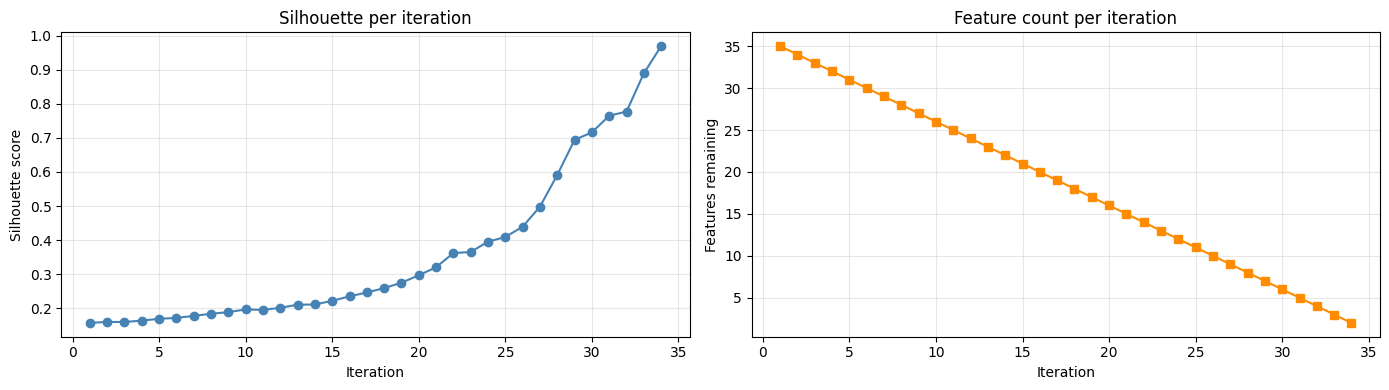

 Iteration  Num_Features  Best_k  Silhouette  < 5% Clusters                      Dropped_Feature  CV_of_Dropped
         1            35       2      0.1570              0               host_identity_verified         1.4142
         2            34       2      0.1598              0                       is_shared_room         1.4142
         3            33       2      0.1596              0                         is_barcelona         1.4142
         4            32       2      0.1637              0                            is_madrid         1.4142
         5            31       2      0.1689              0                 review_scores_rating         1.4142
         6            30       2      0.1717              0               log1p_bathrooms_number         1.4142
         7            29       2      0.1775              0                           is_central         1.4142
         8            28       2      0.1838              0                 log1p_minimum_nights        

In [74]:
summary_df = pd.DataFrame(iteration_results)

# ── plot silhouette and feature count per iteration ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(summary_df['Iteration'], summary_df['Silhouette'], marker='o', color='steelblue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Silhouette score')
ax1.set_title('Silhouette per iteration')
ax1.grid(True, alpha=0.3)

ax2.plot(summary_df['Iteration'], summary_df['Num_Features'], marker='s', color='darkorange')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Features remaining')
ax2.set_title('Feature count per iteration')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── full summary table ────────────────────────────────────────────────────────
display_cols = ['Iteration','Num_Features','Best_k','Silhouette','< 5% Clusters',
                'Dropped_Feature','CV_of_Dropped']
print(summary_df[display_cols].to_string(index=False))

## Phase 9 — Choose the Winning Iteration

Review `summary_df` above and pick the iteration that best balances:
- **High silhouette** (well-separated clusters)
- **Interpretable k** (small number of meaningful segments)
- **Sensible feature count** (not too sparse)
- **Few/no < 5% micro-clusters**
- **Non-trivial CV of the next feature to be dropped**

Set `WINNING_ITERATION` below, then run the cell.

In [93]:
# ── SET THIS after reviewing the table above ──────────────────────────────────
WINNING_ITERATION = 22  # <-- update me

winning_row         = summary_df[summary_df['Iteration'] == WINNING_ITERATION].iloc[0]
FINAL_CLUSTER_FEATURES = [f.strip() for f in winning_row['Remaining_Features'].split(',')]
K_FINAL             = int(winning_row['Best_k'])

print(f"Winning iteration  : {WINNING_ITERATION}")
print(f"Final k            : {K_FINAL}")
print(f"Silhouette         : {winning_row['Silhouette']:.4f}")
print(f"< 5% clusters      : {winning_row['< 5% Clusters']}")
print(f"Feature dropped next (if iteration continues): {winning_row['Dropped_Feature']}  (CV={winning_row['CV_of_Dropped']:.4f})")
print(f"\nFinal features ({len(FINAL_CLUSTER_FEATURES)}):")
for f in FINAL_CLUSTER_FEATURES:
    print(f"  {f}")

Winning iteration  : 22
Final k            : 5
Silhouette         : 0.3619
< 5% clusters      : 0
Feature dropped next (if iteration continues): has_dishes_and_silverware  (CV=1.2051)

Final features (14):
  log1p_accommodates
  log1p_beds
  log1p_amenity_count
  has_reviews
  is_entire_place
  is_private_room
  is_fast_responder
  host_acceptance_rate_ord
  host_response_rate_ord
  has_lock_on_bedroom_door
  has_hot_water
  has_hangers
  has_hair_dryer
  has_dishes_and_silverware


## Phase 10 — Validate Final k (Elbow + Silhouette)

Loop `k ∈ [2, 10]` on `FINAL_CLUSTER_FEATURES` and confirm the chosen `k` sits at a defensible elbow / silhouette peak.

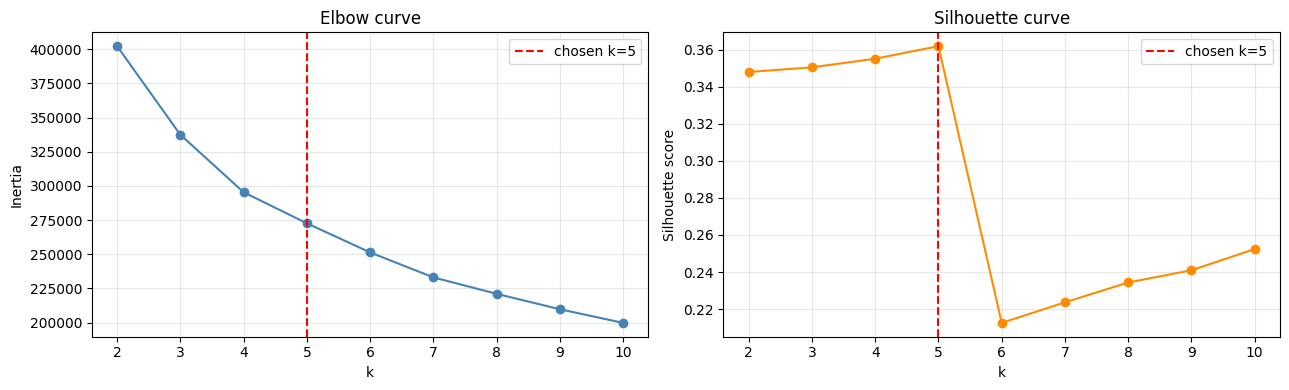

Chosen k=5: inertia=272,694, silhouette=0.3619


In [94]:
X_final = StandardScaler().fit_transform(
    df_segmentation[FINAL_CLUSTER_FEATURES]
)

inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X_final)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_final, km.labels_, sample_size=10_000,
                         random_state=RANDOM_STATE)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(k_range, inertias, marker='o', color='steelblue')
ax1.axvline(K_FINAL, color='red', linestyle='--', label=f'chosen k={K_FINAL}')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouettes, marker='o', color='darkorange')
ax2.axvline(K_FINAL, color='red', linestyle='--', label=f'chosen k={K_FINAL}')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Chosen k={K_FINAL}: inertia={inertias[K_FINAL-2]:,.0f}, silhouette={silhouettes[K_FINAL-2]:.4f}")

## Phase 11 — Fit Final Model & Name Segments

- Refit with `n_init=25, max_iter=500` for a stable final solution.
- Name segments by **mean `price` per cluster**, sorted ascending (lowest → Budget, …, highest → Luxury).
- Re-attach `df_multi_outliers` as the **"Ultra / Extreme"** segment.

In [95]:
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE,
                  n_init=25, max_iter=500)
km_final.fit(X_final)
df_segmentation['Cluster_Final'] = km_final.labels_

# ── name by price rank ────────────────────────────────────────────────────────
_all_names  = ["Budget", "Standard", "Mid-Market", "Premium", "Luxury"]
segment_names = _all_names[:K_FINAL]

price_by_cluster = (
    df_segmentation.groupby('Cluster_Final')['price'].mean().sort_values()
)
name_map = {cluster_id: segment_names[rank]
            for rank, cluster_id in enumerate(price_by_cluster.index)}
df_segmentation['Segment_Name'] = df_segmentation['Cluster_Final'].map(name_map)

# ── mark extreme group ────────────────────────────────────────────────────────
df_multi_outliers = df_multi_outliers.copy()
df_multi_outliers['Cluster_Final'] = -1
df_multi_outliers['Segment_Name']  = 'Ultra / Extreme'

# ── report ────────────────────────────────────────────────────────────────────
final_sil = silhouette_score(X_final, km_final.labels_,
                             sample_size=10_000, random_state=RANDOM_STATE)
print(f"Final silhouette: {final_sil:.4f}")
print()
seg_counts = df_segmentation['Segment_Name'].value_counts().reindex(segment_names)
for seg, n in seg_counts.items():
    print(f"  {seg:<12} {n:>6,}  ({n/len(df_segmentation)*100:.1f}%)  "
          f"mean price={df_segmentation[df_segmentation['Segment_Name']==seg]['price'].mean():.0f}")
n_ext = len(df_multi_outliers)
print(f"  {'Ultra/Extreme':<12} {n_ext:>6,}  ({n_ext/(len(df_segmentation)+n_ext)*100:.1f}%)")

Final silhouette: 0.3619

  Budget        6,601  (17.1%)  mean price=69
  Standard      2,648  (6.9%)  mean price=137
  Mid-Market   21,889  (56.7%)  mean price=169
  Premium       2,451  (6.4%)  mean price=191
  Luxury        4,988  (12.9%)  mean price=198
  Ultra/Extreme  4,234  (9.9%)


## Phase 12 — Profile & Visualise Segments

In [ ]:
# Combine clean segments + extreme group for profiling
df_all = pd.concat([df_segmentation, df_multi_outliers], axis=0, ignore_index=True)

PROFILE_CONTINUOUS = ['accommodates','bedrooms','bathrooms_number','minimum_nights',
                      'host_tenure_years','review_scores_rating',
                      'calculated_host_listings_count',
                      'amenity_count','description_length']
PROFILE_BINARY     = ['host_is_superhost','instant_bookable','has_reviews',
                      'is_entire_place','is_private_room','is_hotel_hostel','is_shared_room',
                      'is_central','is_madrid','is_barcelona',
                      'is_fast_responder']
PROFILE_TARGETS    = ['price','estimated_occupancy_l365d','estimated_revenue_l365d']
PROFILE_ALL        = PROFILE_CONTINUOUS + PROFILE_BINARY + PROFILE_TARGETS

segment_order = segment_names + ['Ultra / Extreme']
profile_table = (
    df_all.groupby('Segment_Name', observed=True)[PROFILE_ALL]
    .mean()
    .reindex(segment_order)
)

# Pretty-print: binary cols as %, targets separately
display_table = profile_table.copy()
for col in PROFILE_BINARY:
    display_table[col] = (display_table[col] * 100).round(1).astype(str) + '%'
for col in PROFILE_CONTINUOUS + PROFILE_TARGETS:
    display_table[col] = display_table[col].round(2)

display(display_table)

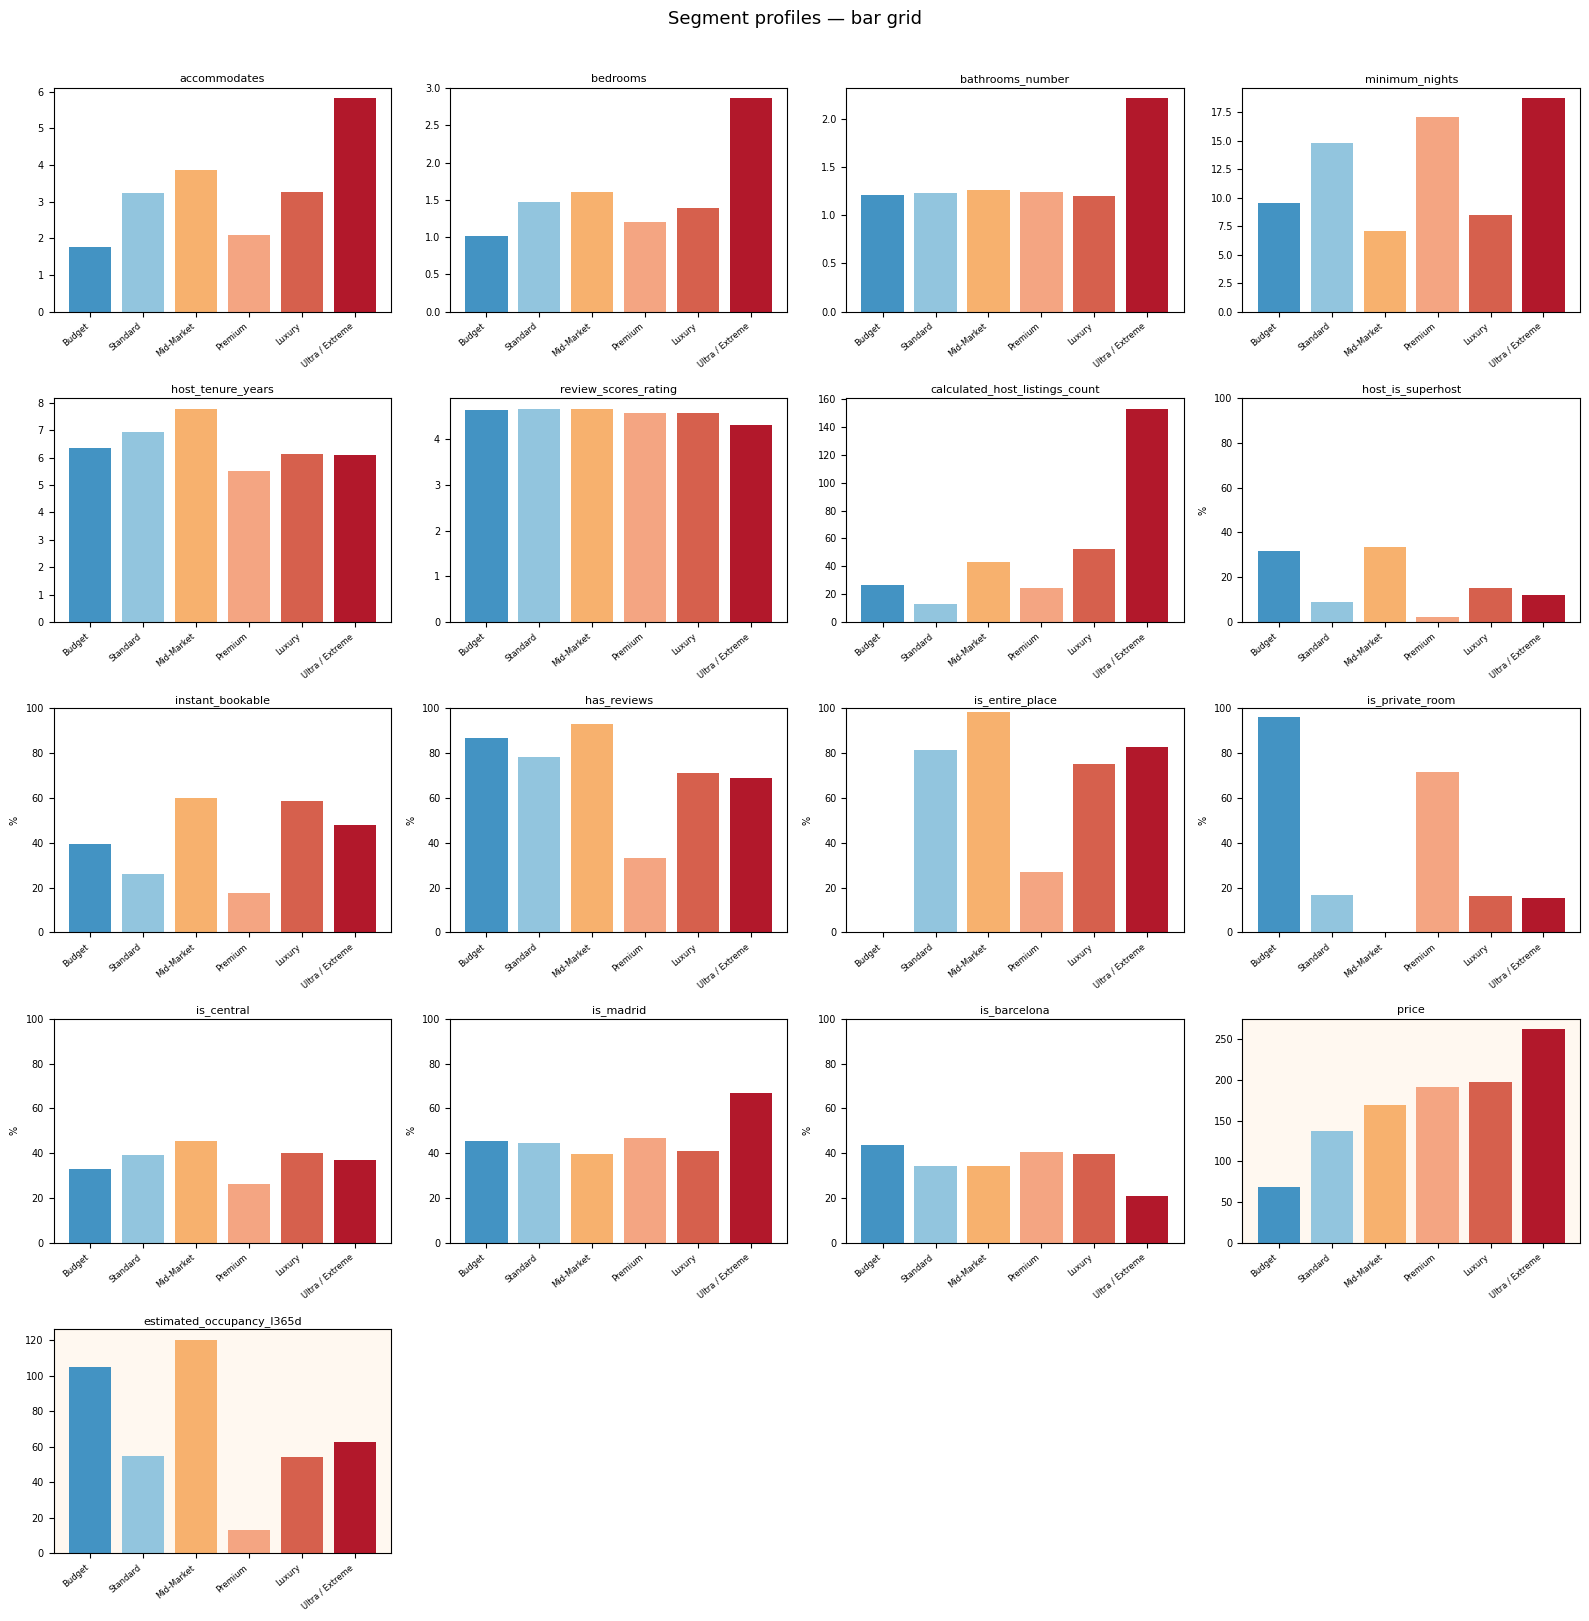

In [97]:
SEGMENT_COLORS = {
    'Budget':          '#4393c3',
    'Standard':        '#92c5de',
    'Mid-Market':      '#f7b16e',
    'Premium':         '#f4a582',
    'Luxury':          '#d6604d',
    'Ultra / Extreme': '#b2182b',
}

plot_segments = [s for s in segment_order if s in profile_table.index]
colors        = [SEGMENT_COLORS.get(s, '#888888') for s in plot_segments]
bar_features  = PROFILE_CONTINUOUS + PROFILE_BINARY + PROFILE_TARGETS

n_cols = 4
n_rows = (len(bar_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for i, feat in enumerate(bar_features):
    ax   = axes[i]
    vals = profile_table.loc[plot_segments, feat]
    is_binary = feat in PROFILE_BINARY
    scale = 100 if is_binary else 1

    ax.bar(range(len(plot_segments)), vals * scale, color=colors)
    ax.set_title(feat, fontsize=8, pad=4)
    ax.set_xticks(range(len(plot_segments)))
    ax.set_xticklabels(plot_segments, rotation=40, ha='right', fontsize=6)
    if is_binary:
        ax.set_ylabel('%', fontsize=7)
        ax.set_ylim(0, 100)
    elif feat in PROFILE_TARGETS:
        ax.set_facecolor('#fff8f0')
    ax.tick_params(axis='y', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Segment profiles — bar grid', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Radar uses 8 features — swap host_tenure_years for estimated_revenue_l365d
# so the investment signal is directly visible on the chart
RADAR_FEATURES = ['accommodates','minimum_nights','review_scores_rating',
                  'estimated_revenue_l365d',
                  'is_entire_place','host_is_superhost',
                  'is_central','instant_bookable']

radar_data = profile_table.loc[plot_segments, RADAR_FEATURES].copy().astype(float)
for col in RADAR_FEATURES:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)
    else:
        radar_data[col] = 0.5

N      = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for seg in plot_segments:
    vals = radar_data.loc[seg, RADAR_FEATURES].tolist()
    vals_closed = vals + vals[:1]
    color = SEGMENT_COLORS.get(seg, '#888888')
    ax.plot(angles_closed, vals_closed, label=seg, color=color, linewidth=2)
    ax.fill(angles_closed, vals_closed, alpha=0.07, color=color)

ax.set_xticks(angles)
ax.set_xticklabels(RADAR_FEATURES, size=9)
ax.set_ylim(0, 1)
ax.set_title('Segment radar (min-max scaled across segments)', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15))
plt.tight_layout()
plt.show()

## Phase 13 — DBSCAN Sanity Check

Run DBSCAN on the same scaled final feature set. Use the k-NN distance plot to choose `eps`, then compare cluster count, noise ratio, and silhouette against the iterative K-Means solution.

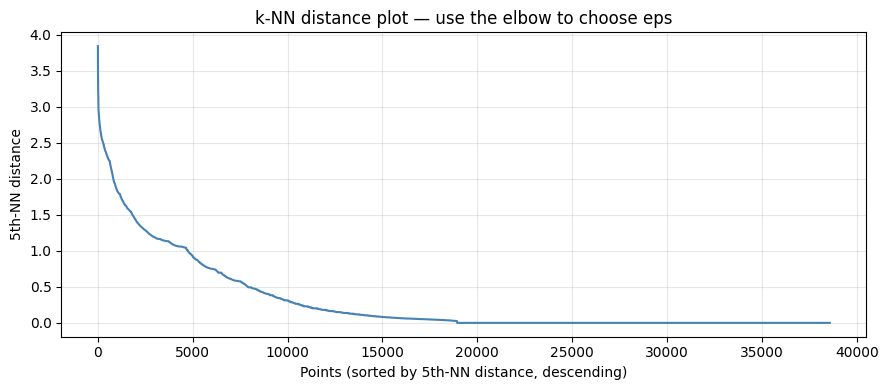

In [99]:
# k-NN distance plot to guide eps selection
nn = NearestNeighbors(n_neighbors=5).fit(X_final)
distances, _ = nn.kneighbors(X_final)
k_distances  = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='steelblue', lw=1.5)
ax.set_xlabel('Points (sorted by 5th-NN distance, descending)')
ax.set_ylabel('5th-NN distance')
ax.set_title('k-NN distance plot — use the elbow to choose eps')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [100]:
# ── SET eps after inspecting the k-NN plot above ─────────────────────────────
EPS         = 1.5   # <-- update me
MIN_SAMPLES = 50

db     = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_final)
db_labels = db.labels_

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_ratio   = (db_labels == -1).mean()

print(f"DBSCAN  eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"  Clusters (excl. noise): {n_db_clusters}")
print(f"  Noise ratio            : {noise_ratio:.1%}")

if n_db_clusters > 1:
    # Silhouette on non-noise points only
    mask_valid = db_labels != -1
    db_sil = silhouette_score(X_final[mask_valid], db_labels[mask_valid],
                              sample_size=10_000, random_state=RANDOM_STATE)
    print(f"  Silhouette (non-noise) : {db_sil:.4f}")
else:
    db_sil = None
    print("  Fewer than 2 clusters — silhouette not computable")

print()
print("── Comparison ────────────────────────────────────────")
print(f"  Method              Clusters  Noise   Silhouette")
print(f"  Iterative K-Means   {K_FINAL:<8}  {'n/a':<6}  {final_sil:.4f}")
if db_sil is not None:
    print(f"  DBSCAN              {n_db_clusters:<8}  {noise_ratio:.1%}   {db_sil:.4f}")
else:
    print(f"  DBSCAN              {n_db_clusters:<8}  {noise_ratio:.1%}   n/a")
print()
print("Conclusion: if DBSCAN produces many micro-clusters or high noise, "
      "iterative K-Means is preferred for interpretability and business use.")

DBSCAN  eps=1.5, min_samples=50
  Clusters (excl. noise): 60
  Noise ratio            : 16.8%
  Silhouette (non-noise) : 0.3989

── Comparison ────────────────────────────────────────
  Method              Clusters  Noise   Silhouette
  Iterative K-Means   5         n/a     0.3619
  DBSCAN              60        16.8%   0.3989

Conclusion: if DBSCAN produces many micro-clusters or high noise, iterative K-Means is preferred for interpretability and business use.


## Phase 14 — Persist Segment Labels

Write `df_all` (all cities, all segments including Ultra / Extreme) with `Segment_Name` and `Cluster_Final` to a new parquet so downstream price and occupancy models can join on listing `id`.

In [101]:
OUTPUT_PATH = "../Data/processed/listings_segmented.parquet"

# Drop the iteration-level cluster column; only the final labels matter downstream
KEEP_COLS = [c for c in df_all.columns if c != 'KMeans_Iter_Cluster']
df_out = df_all[KEEP_COLS].copy()

df_out.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved {len(df_out):,} rows → {OUTPUT_PATH}")
print(f"\nSegment distribution:")
print(df_out['Segment_Name'].value_counts().reindex(segment_order))
print(f"\nColumns written: {len(df_out.columns)}")

Saved 42,811 rows → ../Data/processed/listings_segmented.parquet

Segment distribution:
Segment_Name
Budget              6601
Standard            2648
Mid-Market         21889
Premium             2451
Luxury              4988
Ultra / Extreme     4234
Name: count, dtype: int64

Columns written: 111
